# Assignment 04 — Diabetes BRFSS

## A–C. Bài toán, dữ liệu và preprocessing

Notebook đã execute này nối toán học → NumPy from scratch → PyTorch → TensorFlow/Keras, so sánh Basic/Improved trên parity và chạy Improved full-scale.

Lecture minh họa 8 đặc trưng; project dùng 21 đặc trưng BRFSS. Thứ tự semantic là lựa chọn giảng dạy, không phải locality tự nhiên và không chứng minh CNN tối ưu cho dữ liệu bảng.

Preprocessing/vocabulary chỉ fit train; cùng immutable split, initialization, Adam (lr=1e-3), batch order, tối đa 20 epochs, patience=3. Test không tham gia chọn kiến trúc.

### Mục đích của cell

Nạp metadata và output thực tế đã lưu. Cell chỉ đọc artifact, không split hoặc huấn luyện lại.

In [1]:
from pathlib import Path
import json, inspect
import numpy as np
import pandas as pd
from IPython.display import Image, display
HERE=Path.cwd().resolve()
ROOT=next((p for p in (HERE,*HERE.parents) if (p/'src/assignment04').exists()), None)
assert ROOT is not None, 'Không tìm thấy repository root'
META=json.loads((ROOT/'results/assignment04/manifests/diabetes_preprocessing.json').read_text(encoding='utf-8'))
PARITY=pd.read_csv(ROOT/'results/assignment04/parity/diabetes/parity_results.csv')
ARCH=pd.read_csv(ROOT/'results/assignment04/parity/diabetes/architecture_comparison.csv')
FULL=pd.read_csv(ROOT/'results/assignment04/full_scale/diabetes/full_results.csv')
HISTORY=pd.read_csv(ROOT/'results/assignment04/full_scale/diabetes/training_history.csv')
print({'task':'diabetes','selected':'improved','parity_runs':len(PARITY),'full_runs':len(FULL)})

{'task': 'diabetes', 'selected': 'improved', 'parity_runs': 6, 'full_runs': 2}


### Phân tích kết quả

Đã đọc 6 parity validation runs và đúng 2 full-scale Improved runs (PyTorch, TensorFlow). Không có full NumPy run.

### Mục đích của cell

Kiểm tra số dòng master và preprocessing train-only để phát hiện sai split/leakage trước metric.

In [2]:
display(pd.DataFrame(META['splits']).T); print('fit_split =',META['fit_split'])

,master_class_counts,master_rows,parity_class_counts,parity_rows
test,"{'0.0': 32750, '1.0': 5302}",38052,"{'0.0': 8607, '1.0': 1393}",10000
train,"{'0.0': 152834, '1.0': 24742}",177576,"{'0.0': 34427, '1.0': 5573}",40000
validation,"{'0.0': 32750, '1.0': 5302}",38052,"{'0.0': 8607, '1.0': 1393}",10000


fit_split = master_train_only


### Phân tích kết quả

Master split đúng train=177,576, validation=38,052, test=38,052. Feature order đã khóa: BMI → HighBP → HighChol → CholCheck → HeartDiseaseorAttack → Stroke → Smoker → PhysActivity → Fruits → Veggies → HvyAlcoholConsump → AnyHealthcare → NoDocbcCost → GenHlth → MentHlth → PhysHlth → DiffWalk → Sex → Age → Education → Income.

## D–E. Toán học CNN và tensor shapes

Cross-correlation 1D: $z_{b,o,t}=b_o+\sum_c\sum_j W_{o,c,j}x_{b,c,t+j-p}$. Kernel trượt tạo local connectivity và weight sharing. ReLU $a=\max(0,z)$; max-pooling giữ cực đại cục bộ; dense tạo logits/giá trị hồi quy. Backprop dùng chain rule qua Dense → GlobalMaxPool → Conv; Adam cập nhật parameter từ moment bậc một/hai.

Ví dụ lecture `x=[2,1,3,4,2]`, `k=[0.5,-1,0.5]`: biểu thức số đầu tiên cho **1.5**; implementation/tests theo phép tính trực tiếp, không ép thành 1.

Input: `[B,1,21]`.

| Kiến trúc | Dòng tensor sau input |
|---|---|
| Basic | Conv1 `[B,8,L]` → Conv2 `[B,16,L]` → MaxPool `[B,16,L/2]` → GlobalMax `[B,16]` → Output |
| Improved | Conv1 `[B,8,L]` → Conv2 `[B,16,L]` → MaxPool → Conv3 `[B,32,L/2]` → GlobalMax `[B,32]` → Hidden `[B,16]` → Output |

Basic có 3 và Improved có 5 trainable conv/dense transformations; ReLU/pooling không tính là trainable layer. Không có embedding/field encoder.

### Mục đích của cell

Tính sliding window và in đúng source cốt lõi/model task-specific để kiểm tra forward, gradient và update.

In [3]:
x=np.array([2,1,3,4,2.]); k=np.array([.5,-1,.5]); print('hand convolution:',[x[i:i+3]@k for i in range(3)])
from src.assignment04.scratch_layers import Conv1D, ReLU, MaxPool1D, Dense
from src.assignment04.scratch_losses import SoftmaxCrossEntropyLoss
from src.assignment04.scratch_optim import Adam
from src.assignment04.scratch_models import ScratchCNN
from src.assignment04.torch_models import TorchCNN
from src.assignment04.tensorflow_models import TFCNN
print('--- Conv1D forward/backward (NumPy) ---')
print(inspect.getsource(Conv1D.forward)); print(inspect.getsource(Conv1D.backward))
print('--- ReLU, pooling, dense, loss, Adam ---')
for obj in [ReLU, MaxPool1D.forward, MaxPool1D.backward, Dense.backward, SoftmaxCrossEntropyLoss.forward, SoftmaxCrossEntropyLoss.backward, Adam.step]:
    print(inspect.getsource(obj))
print('--- Model/encoder thực sự dùng cho diabetes ---')
for obj in [ScratchCNN.forward, ScratchCNN.backward, TorchCNN.forward, TFCNN.call]:
    print(inspect.getsource(obj))

hand convolution: [np.float64(1.5), np.float64(-0.5), np.float64(-1.5)]


--- Conv1D forward/backward (NumPy) ---
    def forward(self, x):
        x = np.asarray(x)
        if x.ndim != 3 or x.shape[1] != self.weight.shape[1]:
            raise ValueError("Conv1D input must have shape [B, C_in, L]")
        x_pad = np.pad(x, ((0, 0), (0, 0), (self.pad, self.pad)))
        windows = np.lib.stride_tricks.sliding_window_view(x_pad, self.kernel_size, axis=2)
        output = np.einsum("bclk,ock->bol", windows, self.weight) + self.bias[None, :, None]
        self._cache = (x.shape, x_pad, windows)
        return output

    def backward(self, grad_output):
        if self._cache is None:
            raise RuntimeError("forward must be called before backward")
        original_shape, x_pad, windows = self._cache
        grad_output = np.asarray(grad_output)
        self.grad_weight[...] = np.einsum("bol,bclk->ock", grad_output, windows)
        self.grad_bias[...] = grad_output.sum(axis=(0, 2))
        grad_pad = np.zeros_like(x_pad)
        # Each kernel tap con

### Phân tích kết quả

Output tay là `[1.5, -0.5, -1.5]`. Source cho thấy NumPy tự tạo window, chia sẻ kernel, lưu mask/argmax cho backward, truyền gradient qua embedding/field encoder và Adam cập nhật ndarray; scratch không gọi convolution Torch/TF/SciPy.

## F–K. NumPy verification, Basic/Improved, PyTorch và TensorFlow

Finite-difference kiểm tra gradient; canonical NumPy weights được transpose sang layout từng framework. Parity giữ cùng dữ liệu, batch order và objective. House dùng MSE trên standardized log1p(price), báo metric USD; classification dùng 2 logits và cross-entropy.

### Mục đích của cell

Hiển thị numerical parity và aggregate validation dùng chọn Basic/Improved.

In [4]:
VERIFY=json.loads((ROOT/'results/assignment04/parity/verification.json').read_text(encoding='utf-8')); display(VERIFY); display(ARCH)

{'artifact_checks': {'all_figures_nonempty': True,
  'all_history_losses_finite': True,
  'all_notebooks_executed_without_errors': True,
  'all_numeric_outputs_finite_where_present': True,
  'all_run_keys_once': True,
  'comments_artifact_checksums_verified': True,
  'diabetes_manifest_verified': True,
  'figures': {'comments_parity_loss_curves.png': {'bytes': 129629,
    'exists': True},
   'diabetes_parity_loss_curves.png': {'bytes': 105501, 'exists': True},
   'house_parity_loss_curves.png': {'bytes': 107518, 'exists': True}},
  'house_manifest_verified': True,
  'nonselected_test_metrics_absent': True,
  'notebooks': {'01_diabetes_cnn.ipynb': {'cells': 35,
    'code_cells': 9,
    'error_outputs': 0,
    'executed_code_cells': 9},
   '02_house_price_cnn.ipynb': {'cells': 35,
    'code_cells': 9,
    'error_outputs': 0,
    'executed_code_cells': 9},
   '03_comments_cnn.ipynb': {'cells': 35,
    'code_cells': 9,
    'error_outputs': 0,
    'executed_code_cells': 9}},
  'parameter_co

,architecture,mean_validation_f1,mean_validation_loss
0,improved,0.453796,0.533805
1,basic,0.432574,0.539503


### Phân tích kết quả

Gradient/parity trong tolerance đã khóa. improved: mean validation F1=0.4538, basic: mean validation F1=0.4326. Improved được chọn trước full-scale; Basic không bị mở test lặp.

### Mục đích của cell

Hiển thị đầy đủ metric validation parity và test chỉ của architecture đã chọn.

In [5]:
val_cols=['architecture','implementation','parameter_count','best_epoch','training_seconds']+[c for c in PARITY if c.startswith('validation_')]; display(PARITY[val_cols]); test_cols=['implementation']+[c for c in PARITY if c.startswith('test_')]; display(PARITY.loc[PARITY.architecture.eq('improved'),test_cols])

,architecture,implementation,parameter_count,best_epoch,training_seconds,validation_samples,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_confusion_matrix
0,basic,scratch,466,10,212.839676,10000,0.539543,0.7265,0.304373,0.749462,0.432926,0.802977,"[[6221, 2386], [349, 1044]]"
1,basic,pytorch,466,10,59.988485,10000,0.539436,0.7261,0.303790,0.748026,0.432096,0.803066,"[[6219, 2388], [351, 1042]]"
2,basic,tensorflow,466,10,29.028872,10000,0.539530,0.7252,0.303680,0.752333,0.432700,0.802974,"[[6204, 2403], [345, 1048]]"
3,improved,scratch,2562,7,640.713374,10000,0.535324,0.7743,0.341758,0.669777,0.452583,0.816593,"[[6810, 1797], [460, 933]]"
4,improved,pytorch,2562,7,95.783469,10000,0.534299,0.7745,0.342701,0.674085,0.454391,0.816770,"[[6806, 1801], [454, 939]]"
5,improved,tensorflow,2562,10,86.202441,10000,0.531792,0.7750,0.343098,0.672649,0.454413,0.818475,"[[6813, 1794], [456, 937]]"


,implementation,test_samples,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_confusion_matrix
3,scratch,10000,0.540497,0.7753,0.341382,0.659727,0.449939,0.814731,"[[6834, 1773], [474, 919]]"
4,pytorch,10000,0.539447,0.7752,0.341842,0.663317,0.451172,0.814810,"[[6828, 1779], [469, 924]]"
5,tensorflow,10000,0.536939,0.7753,0.342668,0.667624,0.452885,0.815914,"[[6823, 1784], [463, 930]]"


### Phân tích kết quả

Validation là cơ sở chọn kiến trúc. Test của Basic để trống có chủ ý; chỉ Improved được mở parity-test. Sai khác sau training có thể do floating-point kernels/optimizer dù initial forward đã parity.

## L–N. Full-scale Improved CNN

Không chạy full NumPy scratch vì mục tiêu pedagogical đã hoàn thành ở parity. PyTorch/TensorFlow dùng toàn bộ frozen train/validation và cùng full master-test. Parity-test nằm trong master-test nên full test không phải holdout hoàn toàn mới; không tune sau test.

### Mục đích của cell

Hiển thị best epoch, thời gian và đầy đủ validation/test metrics thực tế của 2 full runs.

In [6]:
cols=['implementation','train_samples','validation_samples','test_samples','parameter_count','best_epoch','epochs_ran','training_seconds']+[c for c in FULL if c.startswith('validation_') or c.startswith('test_')]; display(FULL[cols])

,implementation,train_samples,validation_samples,test_samples,parameter_count,best_epoch,epochs_ran,training_seconds,validation_samples,test_samples,...,validation_f1,validation_roc_auc,validation_confusion_matrix,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_confusion_matrix
0,pytorch,177576,38052,38052,2562,4,7,109.351429,38052,38052,...,0.451688,0.822620,"[[24704, 8046], [1408, 3894]]",0.516573,0.754520,0.328696,0.730856,0.453455,0.824073,"[[24836, 7914], [1427, 3875]]"
1,tensorflow,177576,38052,38052,2562,2,5,60.062431,38052,38052,...,0.452790,0.820815,"[[25115, 7635], [1516, 3786]]",0.520546,0.760827,0.332185,0.709166,0.452440,0.821923,"[[25191, 7559], [1542, 3760]]"


### Phân tích kết quả

PyTorch test: Accuracy=0.7545, Precision=0.3287, Recall=0.7309, F1=0.4535, ROC-AUC=0.8241. TensorFlow test: Accuracy=0.7608, Precision=0.3322, Recall=0.7092, F1=0.4524, ROC-AUC=0.8219. Theo F1, PyTorch cao hơn trong run đã khóa; không dùng kết quả này để tune lại.

### Mục đích của cell

Hiển thị loss curves và confusion matrix/metric plot từ đúng history/full results.

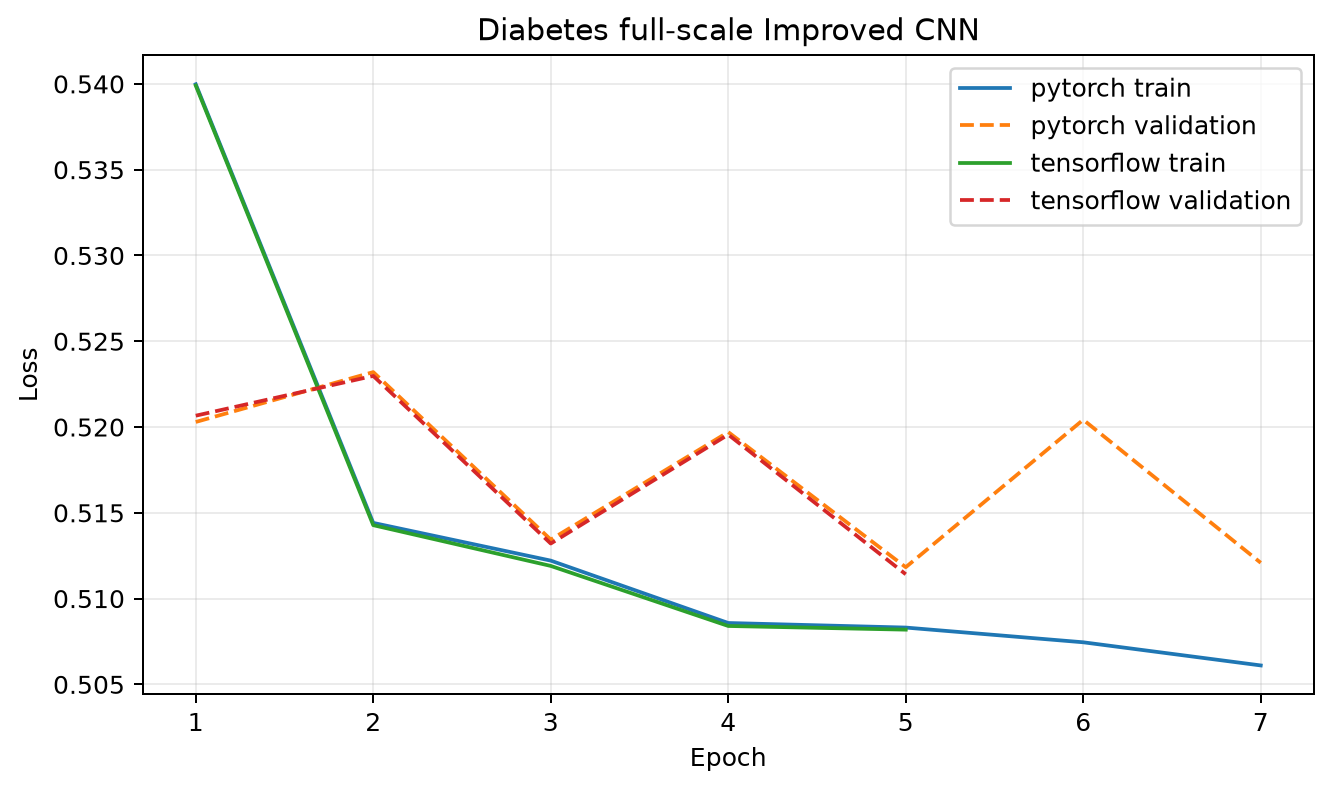

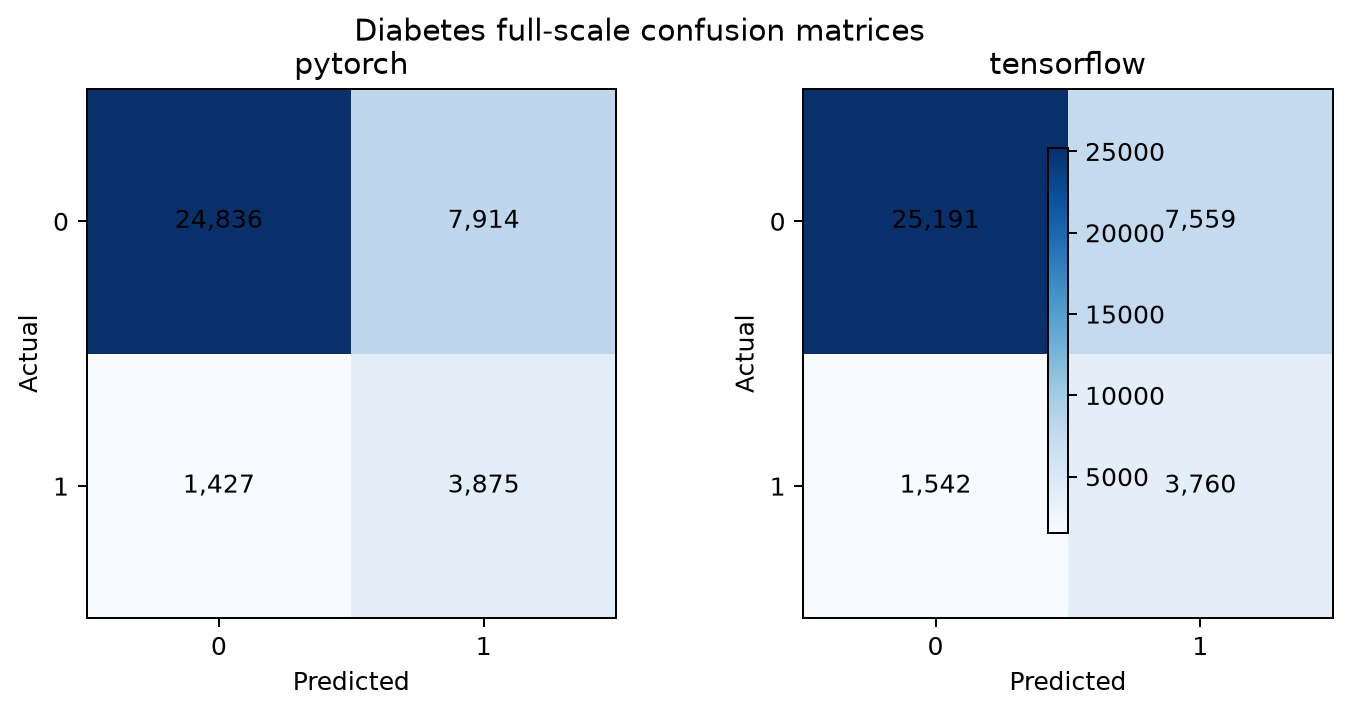

In [7]:
display(Image(filename=str(ROOT/'figures/assignment04/diabetes_full_loss_curves.png'))); display(Image(filename=str(ROOT/'figures/assignment04/diabetes_full_metrics.png')))

### Phân tích kết quả

Gap loss epoch cuối: tensorflow: val−train=+0.0032, pytorch: val−train=+0.0060. Early stopping chọn checkpoint theo validation F1 rồi loss (classification), hoặc RMSE rồi MAE (House); checkpoint tốt nhất được dùng cho test.

## O–Q. So sánh, diễn giải, kết luận và giới hạn

**Basic vs Improved:** improved: mean validation F1=0.4538, basic: mean validation F1=0.4326; Improved được chọn từ parity validation, không phải full test.

**PyTorch vs TensorFlow full-scale:** PyTorch test: Accuracy=0.7545, Precision=0.3287, Recall=0.7309, F1=0.4535, ROC-AUC=0.8241. TensorFlow test: Accuracy=0.7608, Precision=0.3322, Recall=0.7092, F1=0.4524, ROC-AUC=0.8219. Theo F1, PyTorch cao hơn trong run đã khóa; không dùng kết quả này để tune lại.

Kết quả là một seed và CPU. Với Diabetes/House, locality là cấu trúc giảng dạy nên không kết luận CNN tự nhiên tối ưu cho tabular data. House nhạy outlier trên USD dù training dùng log-target. Comments có locality token hợp lý hơn nhưng vẫn chịu vocabulary hữu hạn, OOV, truncation và embedding học từ đầu. Timing phụ thuộc backend/CPU và không đồng nghĩa chất lượng.